In [1]:
import yfinance as yf
import pandas as pd
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Make repo importable =====
# 假设 notebook 在: CS50-analysis/tests/Harmonic_pattern_demo.ipynb
REPO_ROOT = Path.cwd().resolve().parents[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT =", REPO_ROOT)

from stock_analysis.harmonic_patterns.Bat_Harmonic import BatHarmonicPattern
from stock_analysis.config import SLD_WINDOW_CONFIG

REPO_ROOT = C:\Users\17866\OneDrive\桌面\Ltq\2026a\data5703\project\work\current_work\CS50-analysis


In [2]:
# 1. Define tickers and settings
tickers = ["AAPL", "TSLA", "NVDA", "MSFT", "AMZN"]

period = "max"      # ✅ 最大历史数据（核心）
interval = "1d"     # ✅ 日线（适合 harmonic）

# 2. Download OHLC data
data = yf.download(
    tickers=tickers,
    period=period,
    interval=interval,
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True
)

print("Data type:", type(data))
print("Shape:", data.shape)
print("Columns:")
print(data.columns)

# 3. Keep only OHLC columns
ohlc_data = data.loc[:, (slice(None), ['Open', 'High', 'Low', 'Close'])].copy()

print("\nOHLC-only shape:", ohlc_data.shape)

# 4. Convert wide MultiIndex to long format
long_list = []

for ticker in tickers:
    try:
        df_ticker = ohlc_data[ticker].copy().reset_index()

        # ✅ 兼容 Date / Datetime 命名差异
        time_col = df_ticker.columns[0]
        df_ticker = df_ticker.rename(columns={time_col: "Datetime"})

        df_ticker["Ticker"] = ticker

        df_ticker = df_ticker[["Datetime", "Ticker", "Open", "High", "Low", "Close"]]

        df_ticker = df_ticker.dropna(subset=["Open", "High", "Low", "Close"]).copy()

        long_list.append(df_ticker)

    except Exception as e:
        print(f"{ticker}: failed to process -> {e}")

# 5. Merge all tickers
df_long = pd.concat(long_list, ignore_index=True)

# 6. Sort data
df_long = df_long.sort_values(["Ticker", "Datetime"]).reset_index(drop=True)

# 7. Basic inspection
print("\nLong-format data:")
print(df_long.head())

print("\nShape:", df_long.shape)

print("\nRows per ticker:")
print(df_long["Ticker"].value_counts())

# 8. Export
#output_file = "stock_daily_OHLC_long.csv"
#df_long.to_csv(output_file, index=False)
#print(f"\nSaved file: {output_file}")
df_long.head()

Data type: <class 'pandas.core.frame.DataFrame'>
Shape: (11417, 30)
Columns:
MultiIndex([('TSLA',      'Open'),
            ('TSLA',      'High'),
            ('TSLA',       'Low'),
            ('TSLA',     'Close'),
            ('TSLA', 'Adj Close'),
            ('TSLA',    'Volume'),
            ('NVDA',      'Open'),
            ('NVDA',      'High'),
            ('NVDA',       'Low'),
            ('NVDA',     'Close'),
            ('NVDA', 'Adj Close'),
            ('NVDA',    'Volume'),
            ('MSFT',      'Open'),
            ('MSFT',      'High'),
            ('MSFT',       'Low'),
            ('MSFT',     'Close'),
            ('MSFT', 'Adj Close'),
            ('MSFT',    'Volume'),
            ('AAPL',      'Open'),
            ('AAPL',      'High'),
            ('AAPL',       'Low'),
            ('AAPL',     'Close'),
            ('AAPL', 'Adj Close'),
            ('AAPL',    'Volume'),
            ('AMZN',      'Open'),
            ('AMZN',      'High'),
            (

Price,Datetime,Ticker,Open,High,Low,Close
0,1980-12-12,AAPL,0.128348,0.128906,0.128348,0.128348
1,1980-12-15,AAPL,0.122210,0.122210,0.121652,0.121652
2,1980-12-16,AAPL,0.113281,0.113281,0.112723,0.112723
3,1980-12-17,AAPL,0.115513,0.116071,0.115513,0.115513
4,1980-12-18,AAPL,0.118862,0.119420,0.118862,0.118862


## Test and visualization

Bat Pattern

In [3]:
def scan_bat_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 60,
) -> pd.DataFrame:
    """
    Scan one ticker's dataframe with sliding windows
    and run only Bat harmonic detector.
    """
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [4]:
def scan_all_bat_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = BatHarmonicPattern()
    window_size = 60 #SLD_WINDOW_CONFIG["harmonic_patterns"]["window_size"]

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()
        results_ticker = scan_bat_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )
        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [5]:
bat_results = scan_all_bat_patterns(df_long)

print("Total detected Bat patterns:", len(bat_results))

if bat_results.empty:
    print("No Bat harmonic patterns detected.")
else:
    print("\nCounts by ticker:")
    print(bat_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        bat_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 60
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Bat patterns: 4740

Counts by ticker:
Ticker
AMZN    1227
AAPL    1163
MSFT     925
TSLA     752
NVDA     673
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
2190,AMZN,2021-05-28,BatHarmonicPattern,harmonic,40.63,5990,6049
2191,AMZN,2021-06-01,BatHarmonicPattern,harmonic,40.63,5991,6050
2192,AMZN,2021-06-02,BatHarmonicPattern,harmonic,40.63,5992,6051
2193,AMZN,2021-06-03,BatHarmonicPattern,harmonic,40.63,5993,6052
2194,AMZN,2021-06-04,BatHarmonicPattern,harmonic,40.63,5994,6053
2195,AMZN,2021-06-07,BatHarmonicPattern,harmonic,40.63,5995,6054
2196,AMZN,2021-06-08,BatHarmonicPattern,harmonic,40.63,5996,6055
2197,AMZN,2021-06-09,BatHarmonicPattern,harmonic,40.63,5997,6056
2198,AMZN,2021-06-10,BatHarmonicPattern,harmonic,40.63,5998,6057
2199,AMZN,2021-06-11,BatHarmonicPattern,harmonic,40.63,5999,6058


In [6]:
if bat_results.empty:
    print("No Bat patterns found, cannot select top candidate.")
else:
    top_bat = (
        bat_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Bat candidate:")
    print(top_bat)

    top_ticker = top_bat["Ticker"]
    top_start = int(top_bat["WindowStartIdx"])
    top_end = int(top_bat["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Bat candidate:
Ticker                           AMZN
Datetime          2021-05-28 00:00:00
Pattern            BatHarmonicPattern
Category                     harmonic
Confidence                      40.63
WindowStartIdx                   5990
WindowEndIdx                     6049
Name: 2190, dtype: object

Selected ticker: AMZN
Window: 5990 to 6049
Window shape: (60, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2021-03-05,AMZN,150.250000,150.449997,144.050003,150.022995
1,2021-03-08,AMZN,150.750000,153.229507,147.565506,147.597504
2,2021-03-09,AMZN,150.899506,154.548004,150.257507,153.142502
3,2021-03-10,AMZN,154.922501,155.822998,151.502502,152.882004
4,2021-03-11,AMZN,155.200500,156.589005,154.146500,155.679504


Price,Datetime,Ticker,Open,High,Low,Close
55,2021-05-24,AMZN,160.774994,162.897507,160.524994,162.249496
56,2021-05-25,AMZN,163.333496,163.990997,160.688004,162.952499
57,2021-05-26,AMZN,163.729507,164.786499,162.925507,163.257996
58,2021-05-27,AMZN,162.800003,163.018005,161.501999,161.505493
59,2021-05-28,AMZN,162.100006,162.399506,160.985001,161.153503


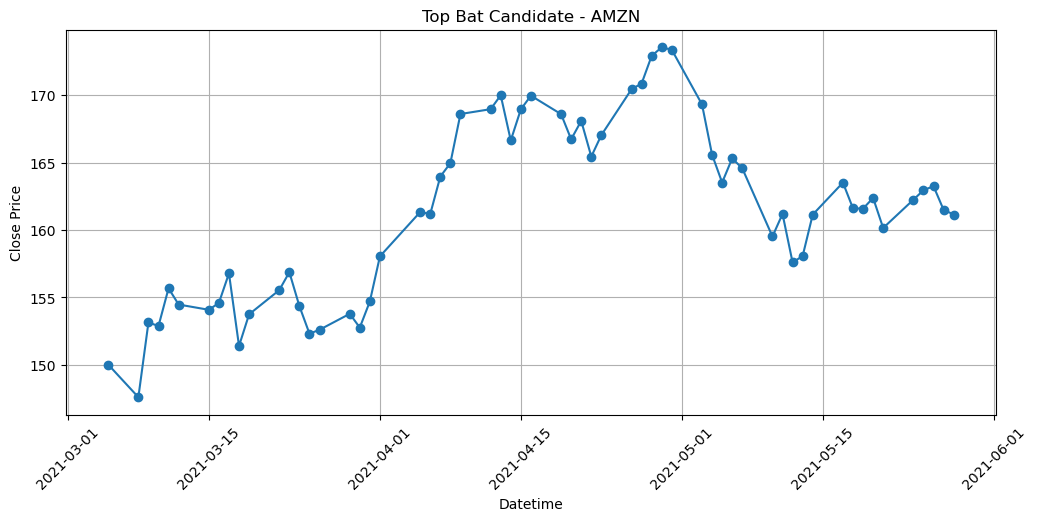

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker='o')

plt.title(f"Top Bat Candidate - {top_ticker}")
plt.xlabel("Datetime")
plt.ylabel("Close Price")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [8]:
from stock_analysis.tools.chart_utils import detect_pivots
from stock_analysis.tools.harmonic_utils import (
    extract_recent_xabcd_candidates,
    build_harmonic_context,
    fib_score,
    range_score,
    average_scores,
    clip_confidence,
    is_valid_xabcd_alternating,
)


def extract_best_bat_candidate(df_window):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    candidates = extract_recent_xabcd_candidates(
        pivots,
        max_candidates=10,
    )

    best = None
    best_score = 0

    for candidate in candidates:
        if not is_valid_xabcd_alternating(candidate):
            continue

        ctx = build_harmonic_context(candidate)
        if ctx is None:
            continue

        ratios = ctx["ratios"]
        direction = ctx["direction"]

        if direction == "unknown":
            continue

        ab_xa = ratios["AB_XA"]
        bc_ab = ratios["BC_AB"]
        cd_bc = ratios["CD_BC"]
        xd_xa = ratios["XD_XA"]

        # ==========================================
        # HARD CONSTRAINTS
        # must match current detector
        # ==========================================
        if not (0.264 <= ab_xa <= 0.618):
            continue

        if not (0.0 <= bc_ab <= 1.390):
            continue

        if not (0.618 <= cd_bc <= 3.618):
            continue

        if not (0.566 <= xd_xa <= 1.206):
            continue

        # ==========================================
        # SOFT SCORING
        # ==========================================
        score_ab = range_score(ab_xa, 0.382, 0.5)
        score_bc = range_score(bc_ab, 0.382, 0.886)
        score_cd = range_score(cd_bc, 1.618, 2.618)
        score_xd = fib_score(xd_xa, 0.886, tol=0.08)

        overall = average_scores([
            score_ab,
            score_bc,
            score_cd,
            score_xd
        ])

        confidence = clip_confidence(overall)

        if confidence > best_score:
            best_score = confidence
            best = {
                "candidate": candidate,
                "confidence": confidence,
                "ratios": ratios,
                "direction": direction,
            }

    return best

In [9]:
best_bat = extract_best_bat_candidate(top_window_df)
print(best_bat)

if best_bat is not None:
    print("\nRatios:")
    for k, v in best_bat["ratios"].items():
        print(k, round(v, 3))

{'candidate': {'types': ['H', 'L', 'H', 'L', 'H'], 'prices': [177.6999969482422, 156.36849975585938, 165.60000610351562, 159.1999969482422, 164.7864990234375], 'indices': [39, 46, 51, 52, 57], 'times': [Timestamp('2021-04-30 00:00:00'), Timestamp('2021-05-11 00:00:00'), Timestamp('2021-05-18 00:00:00'), Timestamp('2021-05-19 00:00:00'), Timestamp('2021-05-26 00:00:00')]}, 'confidence': 40.62936552691095, 'ratios': {'AB_XA': 0.4327641076666993, 'BC_AB': 0.69327896382786, 'CD_BC': 0.8728897005705348, 'XD_XA': 0.6053723190801592}, 'direction': 'bullish'}

Ratios:
AB_XA 0.433
BC_AB 0.693
CD_BC 0.873
XD_XA 0.605


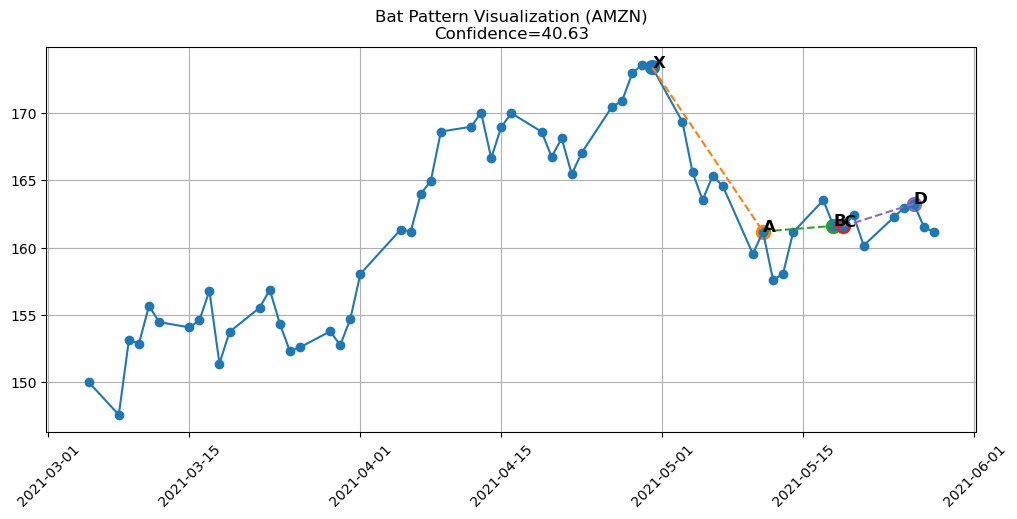

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# price line
plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker='o')

# extract actual pivot indices
candidate = best_bat["candidate"]
pivot_indices = candidate["indices"]

labels = ["X", "A", "B", "C", "D"]

# plot XABCD points
for idx, label in zip(pivot_indices, labels):
    x = top_window_df.iloc[idx]["Datetime"]
    y = top_window_df.iloc[idx]["Close"]

    plt.scatter(x, y, s=100)
    plt.text(x, y, label, fontsize=12, weight='bold')

# connect XABCD
for i in range(len(pivot_indices) - 1):
    x1 = top_window_df.iloc[pivot_indices[i]]["Datetime"]
    y1 = top_window_df.iloc[pivot_indices[i]]["Close"]

    x2 = top_window_df.iloc[pivot_indices[i + 1]]["Datetime"]
    y2 = top_window_df.iloc[pivot_indices[i + 1]]["Close"]

    plt.plot([x1, x2], [y1, y2], linestyle='--')

plt.title(f"Bat Pattern Visualization ({top_ticker})\nConfidence={best_bat['confidence']:.2f}")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Gartley Pattern

In [11]:
from stock_analysis.harmonic_patterns.Gartley_Harmonic import GartleyHarmonicPattern

In [12]:
def scan_gartley_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 60,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [13]:
def scan_all_gartley_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = GartleyHarmonicPattern()
    window_size = 60 #SLD_WINDOW_CONFIG["harmonic_patterns"]["window_size"]

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()
        results_ticker = scan_gartley_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )
        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [14]:
gartley_results = scan_all_gartley_patterns(df_long)

print("Total detected Gartley patterns:", len(gartley_results))

if gartley_results.empty:
    print("No Gartley harmonic patterns detected.")
else:
    print("\nCounts by ticker:")
    print(gartley_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        gartley_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 60
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Gartley patterns: 114

Counts by ticker:
Ticker
AMZN    45
AAPL    35
TSLA    34
Name: count, dtype: int64

Top 20 by confidence:


C:\Users\17866\AppData\Local\Temp\ipykernel_52008\3896064574.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(all_results, ignore_index=True)


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
48,AMZN,2017-04-18,GartleyHarmonicPattern,harmonic,24.67,4954,5013
49,AMZN,2017-04-19,GartleyHarmonicPattern,harmonic,24.67,4955,5014
50,AMZN,2017-04-20,GartleyHarmonicPattern,harmonic,24.67,4956,5015
51,AMZN,2017-04-21,GartleyHarmonicPattern,harmonic,24.67,4957,5016
52,AMZN,2017-04-24,GartleyHarmonicPattern,harmonic,24.67,4958,5017
53,AMZN,2017-04-25,GartleyHarmonicPattern,harmonic,24.67,4959,5018
54,AMZN,2017-04-26,GartleyHarmonicPattern,harmonic,24.67,4960,5019
55,AMZN,2017-04-27,GartleyHarmonicPattern,harmonic,24.67,4961,5020
56,AMZN,2017-04-28,GartleyHarmonicPattern,harmonic,24.67,4962,5021
57,AMZN,2017-05-01,GartleyHarmonicPattern,harmonic,24.67,4963,5022


In [15]:
if gartley_results.empty:
    print("No Gartley patterns found, cannot select top candidate.")
else:
    top_gartley = (
        gartley_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Gartley candidate:")
    print(top_gartley)

    top_gartley_ticker = top_gartley["Ticker"]
    top_gartley_start = int(top_gartley["WindowStartIdx"])
    top_gartley_end = int(top_gartley["WindowEndIdx"])

    df_top_gartley_ticker = (
        df_long[df_long["Ticker"] == top_gartley_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_gartley_window_df = df_top_gartley_ticker.iloc[
        top_gartley_start:top_gartley_end + 1
    ].reset_index(drop=True)

    print("\nSelected ticker:", top_gartley_ticker)
    print("Window:", top_gartley_start, "to", top_gartley_end)
    print("Window shape:", top_gartley_window_df.shape)

    display(top_gartley_window_df.head())
    display(top_gartley_window_df.tail())

Top Gartley candidate:
Ticker                              AMZN
Datetime             2017-04-18 00:00:00
Pattern           GartleyHarmonicPattern
Category                        harmonic
Confidence                         24.67
WindowStartIdx                      4954
WindowEndIdx                        5013
Name: 48, dtype: object

Selected ticker: AMZN
Window: 4954 to 5013
Window shape: (60, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2017-01-23,AMZN,40.340000,40.924999,40.254002,40.894001
1,2017-01-24,AMZN,41.099998,41.199501,40.724998,41.122002
2,2017-01-25,AMZN,41.289501,41.870998,41.264500,41.826000
3,2017-01-26,AMZN,41.776501,42.192001,41.650002,41.957500
4,2017-01-27,AMZN,41.950001,41.985001,41.472000,41.788502


Price,Datetime,Ticker,Open,High,Low,Close
55,2017-04-11,AMZN,45.352001,45.562000,44.875000,45.118000
56,2017-04-12,AMZN,45.154499,45.204498,44.762501,44.811501
57,2017-04-13,AMZN,44.572498,44.748501,44.224499,44.233501
58,2017-04-17,AMZN,44.375000,45.118999,44.375000,45.099499
59,2017-04-18,AMZN,45.049500,45.480499,45.039001,45.188999


In [16]:
from stock_analysis.tools.chart_utils import detect_pivots
from stock_analysis.tools.harmonic_utils import (
    extract_recent_xabcd_candidates,
    build_harmonic_context,
    fib_score,
    range_score,
    average_scores,
    clip_confidence,
    is_valid_xabcd_alternating,
)

def extract_best_gartley_candidate(df_window):
    # Keep pivot settings exactly aligned with detector
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    candidates = extract_recent_xabcd_candidates(
        pivots,
        max_candidates=10,
    )

    best = None
    best_score = 0

    for candidate in candidates:
        if not is_valid_xabcd_alternating(candidate):
            continue

        ctx = build_harmonic_context(candidate)
        if ctx is None:
            continue

        ratios = ctx["ratios"]
        direction = ctx["direction"]

        if direction == "unknown":
            continue

        ab_xa = ratios["AB_XA"]
        bc_ab = ratios["BC_AB"]
        cd_bc = ratios["CD_BC"]
        xd_xa = ratios["XD_XA"]

        # ==========================================
        # HARD CONSTRAINTS
        # Must match current detector exactly
        # ==========================================

        # AB ≈ 0.618, tol = 0.08 -> hard: [0.378, 0.858]
        if not (0.378 <= ab_xa <= 0.858):
            continue

        # BC in [0.382, 0.886], expanded by 50% width -> [0.130, 1.138]
        if not (0.130 <= bc_ab <= 1.138):
            continue

        # CD in [1.272, 1.618], expanded by 50% width -> [1.099, 1.791]
        if not (1.099 <= cd_bc <= 1.791):
            continue

        # XD ≈ 0.786, tol = 0.08 -> hard: [0.546, 1.026]
        if not (0.546 <= xd_xa <= 1.026):
            continue

        # ==========================================
        # SOFT CONFIDENCE SCORING
        # Must match detector exactly
        # ==========================================
        score_ab = fib_score(ab_xa, 0.618, tol=0.08)
        score_bc = range_score(bc_ab, 0.382, 0.886)
        score_cd = range_score(cd_bc, 1.272, 1.618)
        score_xd = fib_score(xd_xa, 0.786, tol=0.08)

        overall = average_scores([
            score_ab,
            score_bc,
            score_cd,
            score_xd
        ])

        confidence = clip_confidence(overall)

        if confidence > best_score:
            best_score = confidence
            best = {
                "candidate": candidate,
                "confidence": confidence,
                "ratios": ratios,
                "direction": direction,
            }

    return best

In [17]:
best_gartley = extract_best_gartley_candidate(top_gartley_window_df)

print("Best Gartley candidate:")
print(best_gartley)

print("\nRatios:")
for k, v in best_gartley["ratios"].items():
    print(k, round(v, 3))

Best Gartley candidate:
{'candidate': {'types': ['L', 'H', 'L', 'H', 'L'], 'prices': [41.67499923706055, 46.18600082397461, 44.46549987792969, 45.5620002746582, 44.2244987487793], 'indices': [44, 51, 53, 55, 57], 'times': [Timestamp('2017-03-27 00:00:00'), Timestamp('2017-04-05 00:00:00'), Timestamp('2017-04-07 00:00:00'), Timestamp('2017-04-11 00:00:00'), Timestamp('2017-04-13 00:00:00')]}, 'confidence': 24.67116922220255, 'ratios': {'AB_XA': 0.3814010952769143, 'BC_AB': 0.6373146142401983, 'CD_BC': 1.2197911919315616, 'XD_XA': 0.5651737120010283}, 'direction': 'bearish'}

Ratios:
AB_XA 0.381
BC_AB 0.637
CD_BC 1.22
XD_XA 0.565


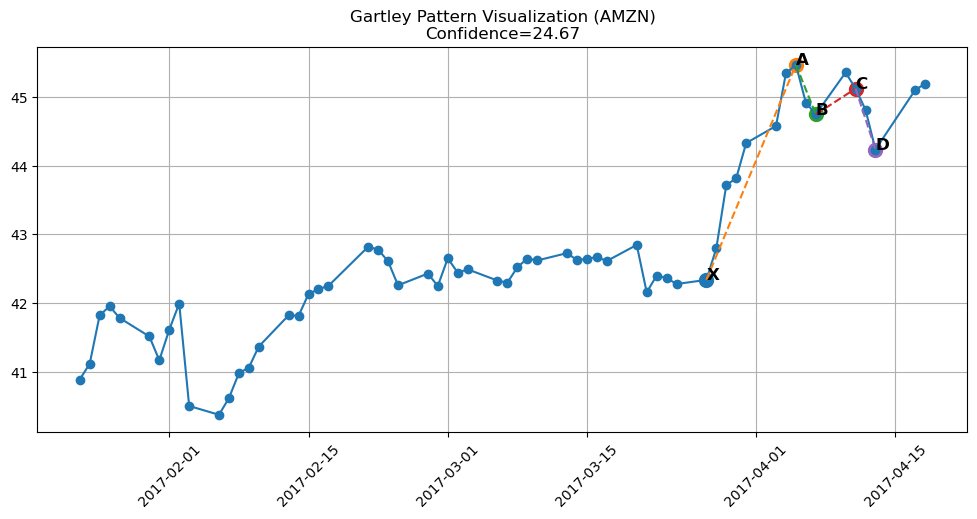

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# price line
plt.plot(top_gartley_window_df["Datetime"], top_gartley_window_df["Close"], marker='o')

candidate = best_gartley["candidate"]
pivot_indices = candidate["indices"]

labels = ["X", "A", "B", "C", "D"]

# plot XABCD points
for idx, label in zip(pivot_indices, labels):
    x = top_gartley_window_df.iloc[idx]["Datetime"]
    y = top_gartley_window_df.iloc[idx]["Close"]

    plt.scatter(x, y, s=100)
    plt.text(x, y, label, fontsize=12, weight='bold')

# connect XABCD
for i in range(len(pivot_indices) - 1):
    x1 = top_gartley_window_df.iloc[pivot_indices[i]]["Datetime"]
    y1 = top_gartley_window_df.iloc[pivot_indices[i]]["Close"]

    x2 = top_gartley_window_df.iloc[pivot_indices[i + 1]]["Datetime"]
    y2 = top_gartley_window_df.iloc[pivot_indices[i + 1]]["Close"]

    plt.plot([x1, x2], [y1, y2], linestyle='--')

plt.title(
    f"Gartley Pattern Visualization ({top_gartley_ticker})\n"
    f"Confidence={best_gartley['confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Butterfly Pattern

In [19]:
from stock_analysis.harmonic_patterns.Butterfly_Harmonic import ButterflyHarmonicPattern

In [20]:
def scan_butterfly_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 60,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [21]:
def scan_all_butterfly_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = ButterflyHarmonicPattern()
    window_size = 60 #SLD_WINDOW_CONFIG["harmonic_patterns"]["window_size"]

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()
        results_ticker = scan_butterfly_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )
        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [22]:
butterfly_results = scan_all_butterfly_patterns(df_long)

print("Total detected Butterfly patterns:", len(butterfly_results))

if butterfly_results.empty:
    print("No Butterfly harmonic patterns detected.")
else:
    print("\nCounts by ticker:")
    print(butterfly_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        butterfly_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 60
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Butterfly patterns: 1010

Counts by ticker:
Ticker
MSFT    388
AAPL    225
NVDA    208
AMZN    142
TSLA     47
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
79,AAPL,1995-09-19,ButterflyHarmonicPattern,harmonic,34.4,3674,3733
80,AAPL,1995-09-20,ButterflyHarmonicPattern,harmonic,34.4,3675,3734
81,AAPL,1995-09-21,ButterflyHarmonicPattern,harmonic,34.4,3676,3735
82,AAPL,1995-09-22,ButterflyHarmonicPattern,harmonic,34.4,3677,3736
83,AAPL,1995-09-25,ButterflyHarmonicPattern,harmonic,34.4,3678,3737
84,AAPL,1995-09-26,ButterflyHarmonicPattern,harmonic,34.4,3679,3738
85,AAPL,1995-09-27,ButterflyHarmonicPattern,harmonic,34.4,3680,3739
86,AAPL,1995-09-28,ButterflyHarmonicPattern,harmonic,34.4,3681,3740
87,AAPL,1995-09-29,ButterflyHarmonicPattern,harmonic,34.4,3682,3741
88,AAPL,1995-10-02,ButterflyHarmonicPattern,harmonic,34.4,3683,3742


In [23]:
if butterfly_results.empty:
    print("No Butterfly patterns found, cannot select top candidate.")
else:
    top_butterfly = (
        butterfly_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Butterfly candidate:")
    print(top_butterfly)

    top_butterfly_ticker = top_butterfly["Ticker"]
    top_butterfly_start = int(top_butterfly["WindowStartIdx"])
    top_butterfly_end = int(top_butterfly["WindowEndIdx"])

    df_top_butterfly_ticker = (
        df_long[df_long["Ticker"] == top_butterfly_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_butterfly_window_df = df_top_butterfly_ticker.iloc[
        top_butterfly_start:top_butterfly_end + 1
    ].reset_index(drop=True)

    print("\nSelected ticker:", top_butterfly_ticker)
    print("Window:", top_butterfly_start, "to", top_butterfly_end)
    print("Window shape:", top_butterfly_window_df.shape)

    display(top_butterfly_window_df.head())
    display(top_butterfly_window_df.tail())

Top Butterfly candidate:
Ticker                                AAPL
Datetime               1995-09-19 00:00:00
Pattern           ButterflyHarmonicPattern
Category                          harmonic
Confidence                            34.4
WindowStartIdx                        3674
WindowEndIdx                          3733
Name: 79, dtype: object

Selected ticker: AAPL
Window: 3674 to 3733
Window shape: (60, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,1995-06-26,AAPL,0.430804,0.433036,0.425223,0.429688
1,1995-06-27,AAPL,0.422991,0.430804,0.414063,0.414063
2,1995-06-28,AAPL,0.410714,0.424107,0.405134,0.416295
3,1995-06-29,AAPL,0.414063,0.429688,0.410714,0.421875
4,1995-06-30,AAPL,0.421875,0.427455,0.411830,0.414621


Price,Datetime,Ticker,Open,High,Low,Close
55,1995-09-13,AAPL,0.382813,0.387277,0.375000,0.378348
56,1995-09-14,AAPL,0.369420,0.371652,0.354911,0.357143
57,1995-09-15,AAPL,0.333705,0.356027,0.316964,0.320313
58,1995-09-18,AAPL,0.324777,0.328683,0.320313,0.327567
59,1995-09-19,AAPL,0.328125,0.331473,0.322545,0.328125


In [24]:
from stock_analysis.tools.chart_utils import detect_pivots
from stock_analysis.tools.harmonic_utils import (
    extract_recent_xabcd_candidates,
    build_harmonic_context,
    fib_score,
    range_score,
    average_scores,
    clip_confidence,
    is_valid_xabcd_alternating,
)

def extract_best_butterfly_candidate(df_window):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    candidates = extract_recent_xabcd_candidates(
        pivots,
        max_candidates=10,
    )

    best = None
    best_score = 0

    for candidate in candidates:
        if not is_valid_xabcd_alternating(candidate):
            continue

        ctx = build_harmonic_context(candidate)
        if ctx is None:
            continue

        ratios = ctx["ratios"]
        direction = ctx["direction"]

        if direction == "unknown":
            continue

        ab_xa = ratios["AB_XA"]
        bc_ab = ratios["BC_AB"]
        cd_bc = ratios["CD_BC"]
        xd_xa = ratios["XD_XA"]

        # ==========================================
        # HARD CONSTRAINTS
        # ==========================================
        if not (0.546 <= ab_xa <= 1.026):
            continue

        if not (0.0 <= bc_ab <= 1.264):
            continue

        if not (0.868 <= cd_bc <= 3.368):
            continue

        if not (1.096 <= xd_xa <= 1.792):
            continue

        # ==========================================
        # SOFT SCORING
        # ==========================================
        score_ab = fib_score(ab_xa, 0.786, tol=0.08)
        score_bc = range_score(bc_ab, 0.382, 0.886)
        score_cd = range_score(cd_bc, 1.618, 2.618)
        score_xd = range_score(xd_xa, 1.27, 1.618)

        overall = average_scores([
            score_ab,
            score_bc,
            score_cd,
            score_xd
        ])

        confidence = clip_confidence(overall)

        if confidence > best_score:
            best_score = confidence
            best = {
                "candidate": candidate,
                "confidence": confidence,
                "ratios": ratios,
                "direction": direction,
            }

    return best

In [25]:
best_butterfly = extract_best_butterfly_candidate(top_butterfly_window_df)

print("Best Butterfly candidate:")
print(best_butterfly)

print("\nRatios:")
for k, v in best_butterfly["ratios"].items():
    print(k, round(v, 3))

Best Butterfly candidate:
{'candidate': {'types': ['L', 'H', 'L', 'H', 'L'], 'prices': [0.373883992433548, 0.4129459857940674, 0.3794640004634857, 0.40625, 0.3169640004634857], 'indices': [33, 42, 45, 53, 57], 'times': [Timestamp('1995-08-11 00:00:00'), Timestamp('1995-08-24 00:00:00'), Timestamp('1995-08-29 00:00:00'), Timestamp('1995-09-11 00:00:00'), Timestamp('1995-09-15 00:00:00')]}, 'confidence': 34.403829592661324, 'ratios': {'AB_XA': 0.8571499416725223, 'BC_AB': 0.8000122833829861, 'CD_BC': 3.333308485083818, 'XD_XA': 1.457170693894803}, 'direction': 'bearish'}

Ratios:
AB_XA 0.857
BC_AB 0.8
CD_BC 3.333
XD_XA 1.457


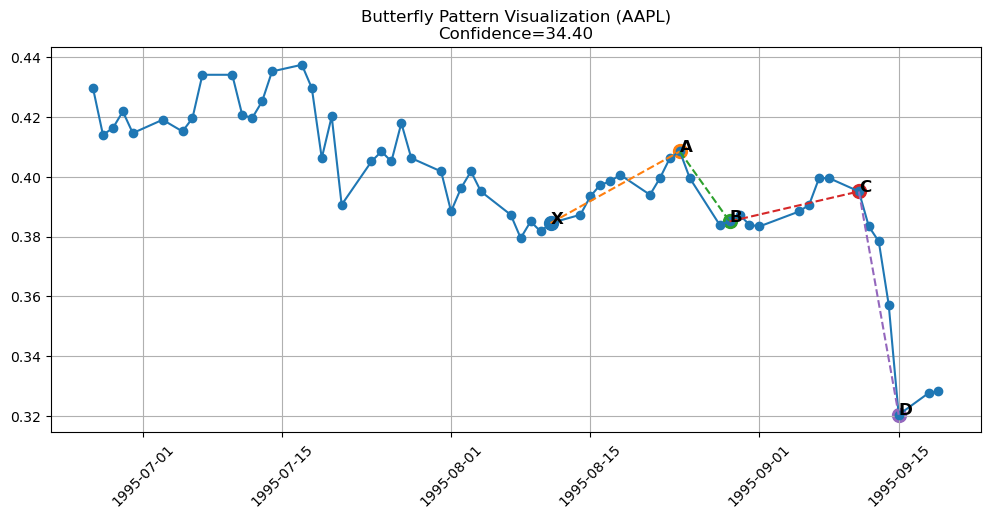

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# price line
plt.plot(top_butterfly_window_df["Datetime"], top_butterfly_window_df["Close"], marker='o')

candidate = best_butterfly["candidate"]
pivot_indices = candidate["indices"]

labels = ["X", "A", "B", "C", "D"]

for idx, label in zip(pivot_indices, labels):
    x = top_butterfly_window_df.iloc[idx]["Datetime"]
    y = top_butterfly_window_df.iloc[idx]["Close"]

    plt.scatter(x, y, s=100)
    plt.text(x, y, label, fontsize=12, weight='bold')

for i in range(len(pivot_indices) - 1):
    x1 = top_butterfly_window_df.iloc[pivot_indices[i]]["Datetime"]
    y1 = top_butterfly_window_df.iloc[pivot_indices[i]]["Close"]

    x2 = top_butterfly_window_df.iloc[pivot_indices[i + 1]]["Datetime"]
    y2 = top_butterfly_window_df.iloc[pivot_indices[i + 1]]["Close"]

    plt.plot([x1, x2], [y1, y2], linestyle='--')

plt.title(
    f"Butterfly Pattern Visualization ({top_butterfly_ticker})\n"
    f"Confidence={best_butterfly['confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Crab Pattern

In [27]:
from stock_analysis.harmonic_patterns.Crab_Harmonic import CrabHarmonicPattern

In [28]:
def scan_crab_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 60,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [29]:
def scan_all_crab_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = CrabHarmonicPattern()
    window_size = 60  #SLD_WINDOW_CONFIG["harmonic_patterns"]["window_size"]

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()
        results_ticker = scan_crab_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )
        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [30]:
crab_results = scan_all_crab_patterns(df_long)

print("Total detected Crab patterns:", len(crab_results))

if crab_results.empty:
    print("No Crab harmonic patterns detected.")
else:
    print("\nCounts by ticker:")
    print(crab_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        crab_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 60
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Crab patterns: 214

Counts by ticker:
Ticker
TSLA    112
MSFT     61
AMZN     28
NVDA      9
AAPL      4
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
4,AMZN,2012-09-12,CrabHarmonicPattern,harmonic,32.64,3799,3858
5,AMZN,2012-09-13,CrabHarmonicPattern,harmonic,32.64,3800,3859
6,AMZN,2012-09-14,CrabHarmonicPattern,harmonic,32.64,3801,3860
7,AMZN,2012-09-17,CrabHarmonicPattern,harmonic,32.64,3802,3861
8,AMZN,2012-09-18,CrabHarmonicPattern,harmonic,32.64,3803,3862
9,AMZN,2012-09-19,CrabHarmonicPattern,harmonic,32.64,3804,3863
10,AMZN,2012-09-20,CrabHarmonicPattern,harmonic,32.64,3805,3864
11,AMZN,2012-09-21,CrabHarmonicPattern,harmonic,32.64,3806,3865
12,AMZN,2012-09-24,CrabHarmonicPattern,harmonic,32.64,3807,3866
13,AMZN,2012-09-25,CrabHarmonicPattern,harmonic,32.64,3808,3867


In [31]:
if crab_results.empty:
    print("No Crab patterns found, cannot select top candidate.")
else:
    top_crab = (
        crab_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Crab candidate:")
    print(top_crab)

    top_crab_ticker = top_crab["Ticker"]
    top_crab_start = int(top_crab["WindowStartIdx"])
    top_crab_end = int(top_crab["WindowEndIdx"])

    df_top_crab_ticker = (
        df_long[df_long["Ticker"] == top_crab_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_crab_window_df = df_top_crab_ticker.iloc[
        top_crab_start:top_crab_end + 1
    ].reset_index(drop=True)

    print("\nSelected ticker:", top_crab_ticker)
    print("Window:", top_crab_start, "to", top_crab_end)
    print("Window shape:", top_crab_window_df.shape)

    display(top_crab_window_df.head())
    display(top_crab_window_df.tail())

Top Crab candidate:
Ticker                           AMZN
Datetime          2012-09-12 00:00:00
Pattern           CrabHarmonicPattern
Category                     harmonic
Confidence                      32.64
WindowStartIdx                   3799
WindowEndIdx                     3858
Name: 4, dtype: object

Selected ticker: AMZN
Window: 3799 to 3858
Window shape: (60, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2012-06-19,AMZN,11.1630,11.2600,11.0830,11.2015
1,2012-06-20,AMZN,11.2255,11.2370,11.0420,11.1510
2,2012-06-21,AMZN,11.1920,11.3015,11.0260,11.0285
3,2012-06-22,AMZN,11.0915,11.1255,10.9675,11.1080
4,2012-06-25,AMZN,11.0150,11.0795,10.9000,11.0035


Price,Datetime,Ticker,Open,High,Low,Close
55,2012-09-06,AMZN,12.4115,12.635,12.360,12.5690
56,2012-09-07,AMZN,12.6925,12.971,12.676,12.9570
57,2012-09-10,AMZN,12.9500,13.000,12.841,12.8545
58,2012-09-11,AMZN,12.8800,12.880,12.713,12.7835
59,2012-09-12,AMZN,12.8250,12.889,12.675,12.7815


In [32]:
from stock_analysis.tools.chart_utils import detect_pivots
from stock_analysis.tools.harmonic_utils import (
    extract_recent_xabcd_candidates,
    build_harmonic_context,
    fib_score,
    range_score,
    average_scores,
    clip_confidence,
    is_valid_xabcd_alternating,
)

def extract_best_crab_candidate(df_window):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    candidates = extract_recent_xabcd_candidates(
        pivots,
        max_candidates=10,
    )

    best = None
    best_score = 0

    for candidate in candidates:
        if not is_valid_xabcd_alternating(candidate):
            continue

        ctx = build_harmonic_context(candidate)
        if ctx is None:
            continue

        ratios = ctx["ratios"]
        direction = ctx["direction"]

        if direction == "unknown":
            continue

        ab_xa = ratios["AB_XA"]
        bc_ab = ratios["BC_AB"]
        cd_bc = ratios["CD_BC"]
        xd_xa = ratios["XD_XA"]

        # ==========================================
        # HARD CONSTRAINTS
        # ==========================================
        if not (0.205 <= ab_xa <= 0.795):
            continue

        if not (0.0 <= bc_ab <= 1.264):
            continue

        if not (1.551 <= cd_bc <= 4.307):
            continue

        if not (1.318 <= xd_xa <= 1.918):
            continue

        # ==========================================
        # SOFT SCORING
        # ==========================================
        score_ab = range_score(ab_xa, 0.382, 0.618)
        score_bc = range_score(bc_ab, 0.382, 0.886)
        score_cd = range_score(cd_bc, 2.24, 3.618)
        score_xd = fib_score(xd_xa, 1.618, tol=0.10)

        overall = average_scores([
            score_ab,
            score_bc,
            score_cd,
            score_xd
        ])

        confidence = clip_confidence(overall)

        if confidence > best_score:
            best_score = confidence
            best = {
                "candidate": candidate,
                "confidence": confidence,
                "ratios": ratios,
                "direction": direction,
            }

    return best

In [33]:
best_crab = extract_best_crab_candidate(top_crab_window_df)

print("Best Crab candidate:")
print(best_crab)

print("\nRatios:")
for k, v in best_crab["ratios"].items():
    print(k, round(v, 3))

Best Crab candidate:
{'candidate': {'types': ['H', 'L', 'H', 'L', 'H'], 'prices': [12.036999702453613, 11.432999610900879, 11.899999618530273, 11.550000190734863, 13.0], 'indices': [28, 31, 34, 38, 57], 'times': [Timestamp('2012-07-30 00:00:00'), Timestamp('2012-08-02 00:00:00'), Timestamp('2012-08-07 00:00:00'), Timestamp('2012-08-13 00:00:00'), Timestamp('2012-09-10 00:00:00')]}, 'confidence': 32.63807255679835, 'ratios': {'AB_XA': 0.7731787033820696, 'BC_AB': 0.7494634305727151, 'CD_BC': 4.142863370944493, 'XD_XA': 1.5943711118830328}, 'direction': 'bullish'}

Ratios:
AB_XA 0.773
BC_AB 0.749
CD_BC 4.143
XD_XA 1.594


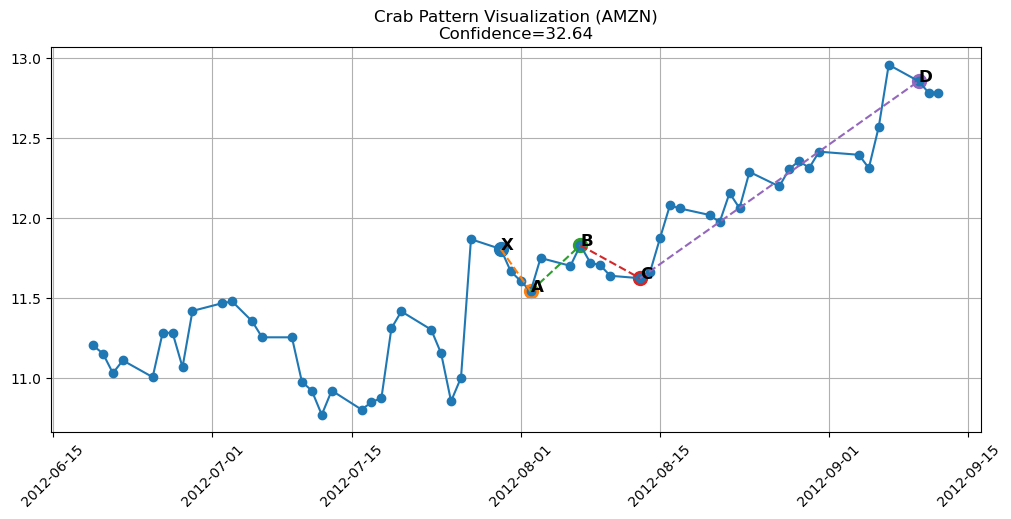

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# price line
plt.plot(top_crab_window_df["Datetime"], top_crab_window_df["Close"], marker='o')

candidate = best_crab["candidate"]
pivot_indices = candidate["indices"]

labels = ["X", "A", "B", "C", "D"]

for idx, label in zip(pivot_indices, labels):
    x = top_crab_window_df.iloc[idx]["Datetime"]
    y = top_crab_window_df.iloc[idx]["Close"]

    plt.scatter(x, y, s=100)
    plt.text(x, y, label, fontsize=12, weight='bold')

for i in range(len(pivot_indices) - 1):
    x1 = top_crab_window_df.iloc[pivot_indices[i]]["Datetime"]
    y1 = top_crab_window_df.iloc[pivot_indices[i]]["Close"]

    x2 = top_crab_window_df.iloc[pivot_indices[i + 1]]["Datetime"]
    y2 = top_crab_window_df.iloc[pivot_indices[i + 1]]["Close"]

    plt.plot([x1, x2], [y1, y2], linestyle='--')

plt.title(
    f"Crab Pattern Visualization ({top_crab_ticker})\n"
    f"Confidence={best_crab['confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Cypher Pattern

In [35]:
from stock_analysis.harmonic_patterns.Cypher_Harmonic import CypherHarmonicPattern

In [36]:
def scan_cypher_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 60,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [37]:
def scan_all_cypher_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = CypherHarmonicPattern()
    window_size = 60 #SLD_WINDOW_CONFIG["harmonic_patterns"]["window_size"]

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()
        results_ticker = scan_cypher_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )
        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [38]:
cypher_results = scan_all_cypher_patterns(df_long)

print("Total detected Cypher patterns:", len(cypher_results))

if cypher_results.empty:
    print("No Cypher harmonic patterns detected.")
else:
    print("\nCounts by ticker:")
    print(cypher_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        cypher_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 60
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Cypher patterns: 7924

Counts by ticker:
Ticker
AAPL    2361
MSFT    1706
NVDA    1638
AMZN    1505
TSLA     714
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
3795,AMZN,2025-03-14,CypherHarmonicPattern,harmonic,70.19,6942,7001
3796,AMZN,2025-03-17,CypherHarmonicPattern,harmonic,70.19,6943,7002
3797,AMZN,2025-03-18,CypherHarmonicPattern,harmonic,70.19,6944,7003
3798,AMZN,2025-03-19,CypherHarmonicPattern,harmonic,70.19,6945,7004
3799,AMZN,2025-03-20,CypherHarmonicPattern,harmonic,70.19,6946,7005
3800,AMZN,2025-03-21,CypherHarmonicPattern,harmonic,70.19,6947,7006
3801,AMZN,2025-03-24,CypherHarmonicPattern,harmonic,70.19,6948,7007
3802,AMZN,2025-03-25,CypherHarmonicPattern,harmonic,70.19,6949,7008
3803,AMZN,2025-03-26,CypherHarmonicPattern,harmonic,70.19,6950,7009
3804,AMZN,2025-03-27,CypherHarmonicPattern,harmonic,70.19,6951,7010


In [39]:
if cypher_results.empty:
    print("No Cypher patterns found, cannot select top candidate.")
else:
    top_cypher = (
        cypher_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Cypher candidate:")
    print(top_cypher)

    top_cypher_ticker = top_cypher["Ticker"]
    top_cypher_start = int(top_cypher["WindowStartIdx"])
    top_cypher_end = int(top_cypher["WindowEndIdx"])

    df_top_cypher_ticker = (
        df_long[df_long["Ticker"] == top_cypher_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_cypher_window_df = df_top_cypher_ticker.iloc[
        top_cypher_start:top_cypher_end + 1
    ].reset_index(drop=True)

    print("\nSelected ticker:", top_cypher_ticker)
    print("Window:", top_cypher_start, "to", top_cypher_end)
    print("Window shape:", top_cypher_window_df.shape)

Top Cypher candidate:
Ticker                             AMZN
Datetime            2025-03-14 00:00:00
Pattern           CypherHarmonicPattern
Category                       harmonic
Confidence                        70.19
WindowStartIdx                     6942
WindowEndIdx                       7001
Name: 3795, dtype: object

Selected ticker: AMZN
Window: 6942 to 7001
Window shape: (60, 6)


In [40]:
from stock_analysis.tools.chart_utils import detect_pivots
from stock_analysis.tools.harmonic_utils import (
    extract_recent_xabcd_candidates,
    build_extended_harmonic_context,
    range_score,
    fib_score,
    average_scores,
    clip_confidence,
    is_valid_xabcd_alternating,
)

def extract_best_cypher_candidate(df_window):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    candidates = extract_recent_xabcd_candidates(
        pivots,
        max_candidates=10,
    )

    best = None
    best_score = 0

    for candidate in candidates:
        if not is_valid_xabcd_alternating(candidate):
            continue

        ctx = build_extended_harmonic_context(candidate)
        if ctx is None:
            continue

        ratios = ctx["ratios"]
        direction = ctx["direction"]

        if direction == "unknown":
            continue

        ab_xa = ratios["AB_XA"]
        xc_xa = ratios["XC_XA"]
        xd_xc = ratios["XD_XC"]

        # ==========================================
        # HARD CONSTRAINTS
        # ==========================================
        if not (0.205 <= ab_xa <= 0.795):
            continue

        if not (1.1655 <= xc_xa <= 1.5205):
            continue

        if not (0.546 <= xd_xc <= 1.026):
            continue

        # ==========================================
        # SOFT SCORING
        # ==========================================
        score_ab = range_score(ab_xa, 0.382, 0.618)
        score_xc = range_score(xc_xa, 1.272, 1.414)
        score_d = fib_score(xd_xc, 0.786, tol=0.08)

        overall = average_scores([
            score_ab,
            score_xc,
            score_d
        ])

        confidence = clip_confidence(overall)

        if confidence > best_score:
            best_score = confidence
            best = {
                "candidate": candidate,
                "confidence": confidence,
                "ratios": ratios,
                "direction": direction,
            }

    return best

In [41]:
best_cypher = extract_best_cypher_candidate(top_cypher_window_df)

print("Best Cypher candidate:")
print(best_cypher)

print("\nRatios:")
for k, v in best_cypher["ratios"].items():
    print(k, round(v, 3))

Best Cypher candidate:
{'candidate': {'types': ['H', 'L', 'H', 'L', 'H'], 'prices': [242.52000427246094, 204.16000366210938, 219.97000122070312, 190.85000610351562, 201.52000427246094], 'indices': [32, 46, 48, 55, 57], 'times': [Timestamp('2025-02-04 00:00:00'), Timestamp('2025-02-25 00:00:00'), Timestamp('2025-02-27 00:00:00'), Timestamp('2025-03-10 00:00:00'), Timestamp('2025-03-12 00:00:00')]}, 'confidence': 70.19256658194885, 'ratios': {'AB_XA': 0.41214800070486374, 'BC_AB': 1.8418722083457193, 'CD_BC': 0.36641483372528305, 'XD_XA': 1.0688216722534678, 'XC_XA': 1.3469759475186767, 'XD_XC': 0.7934972218489802, 'AC_XA': 0.3469759475186767}, 'direction': 'bullish'}

Ratios:
AB_XA 0.412
BC_AB 1.842
CD_BC 0.366
XD_XA 1.069
XC_XA 1.347
XD_XC 0.793
AC_XA 0.347


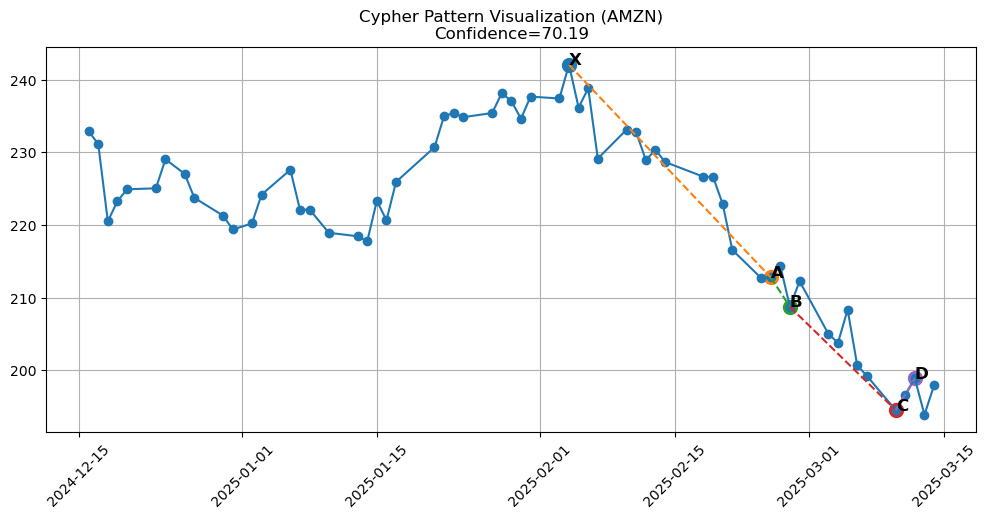

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# price line
plt.plot(top_cypher_window_df["Datetime"], top_cypher_window_df["Close"], marker='o')

candidate = best_cypher["candidate"]
pivot_indices = candidate["indices"]

labels = ["X", "A", "B", "C", "D"]

for idx, label in zip(pivot_indices, labels):
    x = top_cypher_window_df.iloc[idx]["Datetime"]
    y = top_cypher_window_df.iloc[idx]["Close"]

    plt.scatter(x, y, s=100)
    plt.text(x, y, label, fontsize=12, weight='bold')

for i in range(len(pivot_indices) - 1):
    x1 = top_cypher_window_df.iloc[pivot_indices[i]]["Datetime"]
    y1 = top_cypher_window_df.iloc[pivot_indices[i]]["Close"]

    x2 = top_cypher_window_df.iloc[pivot_indices[i + 1]]["Datetime"]
    y2 = top_cypher_window_df.iloc[pivot_indices[i + 1]]["Close"]

    plt.plot([x1, x2], [y1, y2], linestyle='--')

plt.title(
    f"Cypher Pattern Visualization ({top_cypher_ticker})\n"
    f"Confidence={best_cypher['confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Shark Pattern

In [43]:
from stock_analysis.harmonic_patterns.shark_harmonic import SharkHarmonicPattern

In [44]:
def scan_shark_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 60,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [45]:
def scan_all_shark_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = SharkHarmonicPattern()
    window_size = 60 #SLD_WINDOW_CONFIG["harmonic_patterns"]["window_size"]

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()
        results_ticker = scan_shark_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )
        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [46]:
shark_results = scan_all_shark_patterns(df_long)

print("Total detected Shark patterns:", len(shark_results))

if shark_results.empty:
    print("No Shark harmonic patterns detected.")
else:
    print("\nCounts by ticker:")
    print(shark_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        shark_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 60
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Shark patterns: 182

Counts by ticker:
Ticker
NVDA    84
AAPL    50
AMZN    48
Name: count, dtype: int64

Top 20 by confidence:


C:\Users\17866\AppData\Local\Temp\ipykernel_52008\1289303359.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(all_results, ignore_index=True)


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
5,AAPL,2024-04-16,SharkHarmonicPattern,harmonic,42.65,10866,10925
6,AAPL,2024-04-17,SharkHarmonicPattern,harmonic,42.65,10867,10926
7,AAPL,2024-04-18,SharkHarmonicPattern,harmonic,42.65,10868,10927
8,AAPL,2024-04-19,SharkHarmonicPattern,harmonic,42.65,10869,10928
9,AAPL,2024-04-22,SharkHarmonicPattern,harmonic,42.65,10870,10929
10,AAPL,2024-04-23,SharkHarmonicPattern,harmonic,42.65,10871,10930
11,AAPL,2024-04-24,SharkHarmonicPattern,harmonic,42.65,10872,10931
12,AAPL,2024-04-25,SharkHarmonicPattern,harmonic,42.65,10873,10932
13,AAPL,2024-04-26,SharkHarmonicPattern,harmonic,42.65,10874,10933
14,AAPL,2024-04-29,SharkHarmonicPattern,harmonic,42.65,10875,10934


In [47]:
if shark_results.empty:
    print("No Shark patterns found, cannot select top candidate.")
else:
    top_shark = (
        shark_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Shark candidate:")
    print(top_shark)

    top_shark_ticker = top_shark["Ticker"]
    top_shark_start = int(top_shark["WindowStartIdx"])
    top_shark_end = int(top_shark["WindowEndIdx"])

    df_top_shark_ticker = (
        df_long[df_long["Ticker"] == top_shark_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_shark_window_df = df_top_shark_ticker.iloc[
        top_shark_start:top_shark_end + 1
    ].reset_index(drop=True)

    print("\nSelected ticker:", top_shark_ticker)
    print("Window:", top_shark_start, "to", top_shark_end)
    print("Window shape:", top_shark_window_df.shape)

    display(top_shark_window_df.head())
    display(top_shark_window_df.tail())

Top Shark candidate:
Ticker                            AAPL
Datetime           2024-04-16 00:00:00
Pattern           SharkHarmonicPattern
Category                      harmonic
Confidence                       42.65
WindowStartIdx                   10866
WindowEndIdx                     10925
Name: 5, dtype: object

Selected ticker: AAPL
Window: 10866 to 10925
Window shape: (60, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2024-01-22,AAPL,192.300003,195.330002,192.259995,193.889999
1,2024-01-23,AAPL,195.020004,195.750000,193.830002,195.179993
2,2024-01-24,AAPL,195.419998,196.380005,194.339996,194.500000
3,2024-01-25,AAPL,195.220001,196.270004,193.110001,194.169998
4,2024-01-26,AAPL,194.270004,194.759995,191.940002,192.419998


Price,Datetime,Ticker,Open,High,Low,Close
55,2024-04-10,AAPL,168.800003,169.089996,167.110001,167.779999
56,2024-04-11,AAPL,168.339996,175.460007,168.160004,175.039993
57,2024-04-12,AAPL,174.259995,178.360001,174.210007,176.550003
58,2024-04-15,AAPL,175.360001,176.630005,172.500000,172.690002
59,2024-04-16,AAPL,171.750000,173.759995,168.270004,169.380005


In [48]:
from stock_analysis.tools.chart_utils import detect_pivots
from stock_analysis.tools.harmonic_utils import (
    extract_recent_xabcd_candidates,
    build_shark_context,
    is_potential_shark_structure,
    range_score,
    fib_score,
    average_scores,
    clip_confidence,
)

def extract_best_shark_candidate(df_window):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if len(pivots) < 5:
        return None

    candidates = extract_recent_xabcd_candidates(
        pivots,
        max_candidates=10,
    )

    if not candidates:
        return None

    best = None
    best_score = 0

    for candidate in candidates:
        if not is_potential_shark_structure(candidate):
            continue

        ctx = build_shark_context(candidate)
        if ctx is None:
            continue

        ratios = ctx["ratios"]
        direction = ctx["direction"]

        if direction == "unknown":
            continue

        ab_xa = ratios["AB_XA"]   # original XA / OX
        bc_ab = ratios["BC_AB"]   # original AB / XA
        cd_bc = ratios["CD_BC"]   # original BC / AB
        xd_xa = ratios["XD_XA"]   # original OC / OX

        # EXACTLY MATCH SharkHarmonicPattern
        score_xa = range_score(ab_xa, 0.382, 0.618)
        score_ab = range_score(bc_ab, 1.13, 1.618)
        score_bc = range_score(cd_bc, 1.618, 2.24)
        score_c = fib_score(xd_xa, 0.886, tol=0.08)

        overall_score = average_scores([
            score_xa,
            score_ab,
            score_bc,
            score_c,
        ])

        confidence = clip_confidence(overall_score)

        if confidence > best_score:
            best_score = confidence
            best = {
                "candidate": candidate,
                "confidence": confidence,
                "ratios": ratios,
                "direction": direction,
            }

    return best

In [49]:
best_shark = extract_best_shark_candidate(top_shark_window_df)

print("Best Shark candidate:")
print(best_shark)

if best_shark is not None:
    print("\nRatios:")
    for k, v in best_shark["ratios"].items():
        print(k, round(v, 3))

Best Shark candidate:
{'candidate': {'types': ['H', 'L', 'H', 'L', 'H'], 'prices': [173.60000610351562, 168.22999572753906, 171.9199981689453, 167.11000061035156, 178.36000061035156], 'indices': [46, 49, 51, 55, 57], 'times': [Timestamp('2024-03-27 00:00:00'), Timestamp('2024-04-02 00:00:00'), Timestamp('2024-04-04 00:00:00'), Timestamp('2024-04-10 00:00:00'), Timestamp('2024-04-12 00:00:00')]}, 'confidence': 42.6528360507674, 'ratios': {'AB_XA': 0.6871499649076944, 'BC_AB': 1.3035215111566898, 'XC_XA': 1.2085647957400498, 'XD_XC': 0.733434588283423, 'XD_XA': 0.8864032233774426, 'CD_BC': 2.338878526019262}, 'direction': 'bullish'}

Ratios:
AB_XA 0.687
BC_AB 1.304
XC_XA 1.209
XD_XC 0.733
XD_XA 0.886
CD_BC 2.339


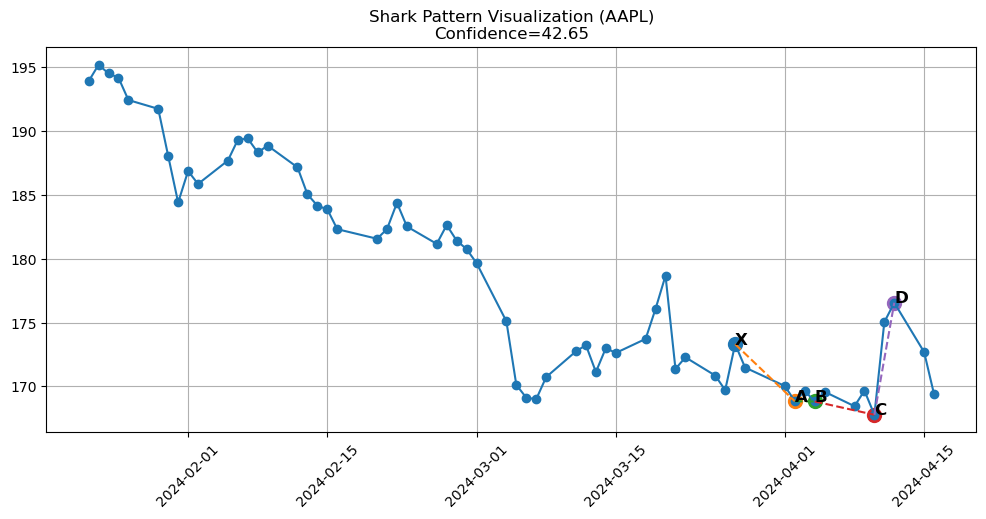

In [50]:
import matplotlib.pyplot as plt

if best_shark is None:
    print("No Shark candidate to visualize.")
else:
    plt.figure(figsize=(12, 5))

    # price line
    plt.plot(top_shark_window_df["Datetime"], top_shark_window_df["Close"], marker='o')

    candidate = best_shark["candidate"]
    pivot_indices = candidate["indices"]

    labels = ["X", "A", "B", "C", "D"]   # 当前框架下的五点命名

    for idx, label in zip(pivot_indices, labels):
        x = top_shark_window_df.iloc[idx]["Datetime"]
        y = top_shark_window_df.iloc[idx]["Close"]

        plt.scatter(x, y, s=100)
        plt.text(x, y, label, fontsize=12, weight='bold')

    for i in range(len(pivot_indices) - 1):
        x1 = top_shark_window_df.iloc[pivot_indices[i]]["Datetime"]
        y1 = top_shark_window_df.iloc[pivot_indices[i]]["Close"]

        x2 = top_shark_window_df.iloc[pivot_indices[i + 1]]["Datetime"]
        y2 = top_shark_window_df.iloc[pivot_indices[i + 1]]["Close"]

        plt.plot([x1, x2], [y1, y2], linestyle='--')

    plt.title(
        f"Shark Pattern Visualization ({top_shark_ticker})\n"
        f"Confidence={best_shark['confidence']:.2f}"
    )
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

In [51]:
if best_shark is not None:
    summary_row = {
        "Pattern": "Shark",
        "Ticker": top_shark_ticker,
        "Confidence": best_shark["confidence"],
        "AB_XA": round(best_shark["ratios"]["AB_XA"], 3),
        "BC_AB": round(best_shark["ratios"]["BC_AB"], 3),
        "CD_BC": round(best_shark["ratios"]["CD_BC"], 3),
        "XD_XA": round(best_shark["ratios"]["XD_XA"], 3),
    }
    print(summary_row)

{'Pattern': 'Shark', 'Ticker': 'AAPL', 'Confidence': 42.6528360507674, 'AB_XA': 0.687, 'BC_AB': 1.304, 'CD_BC': 2.339, 'XD_XA': 0.886}
